# Étape 5b - Duel : forêt aléatoire contre gradient boosting

## Objectif

L'étape 4 a départagé six modèles, mais pas vraiment les deux premiers : 9,495 contre
9,518 de MAE, pour un écart-type entre plis de 0,147. **L'écart est six fois plus petit que
le bruit de mesure.** La forêt a été retenue sur sa stabilité, ce qui est défendable, mais
c'est un départage par défaut : à ce stade, aucun des deux n'avait été optimisé.

Cette étape reprend la question sérieusement :

1. **optimiser chacun séparément**, avec sa propre grille et le même protocole de
   sélection, pour que la comparaison soit équitable ;
2. **mesurer ce qui les sépare vraiment** : leurs prédictions divergent-elles, et où ;
3. **tester si les combiner vaut mieux** que choisir.

**Règle du jeu de test.** Tout ce notebook travaille en validation croisée sur les seules
13 652 formations d'apprentissage. Le jeu de test n'est pas ouvert : s'il l'était pour
départager, il cesserait d'être un jeu de test.

In [1]:
import time

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (GridSearchCV, KFold, cross_val_predict,
                                     cross_validate, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

PROJECT_PATH = Path.cwd().parent
DATA_PATH = PROJECT_PATH / 'csv' / 'dataset_phase3_final.csv'
FIGURE_PATH = PROJECT_PATH / 'figures_eda'

TARGET = "6-Taux d'emploi salarié en France - 6 mois après le diplôme"
SORTANTS = '6-Nombre de sortants - 6 mois après le diplôme'
POURSUIVANTS = '6-Nombre de poursuivants - 6 mois après le diplôme'

COULEUR = '#2f6f9f'
COULEUR_ALT = '#d1793c'
COULEUR_NEUTRE = '#9aa5ad'
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
    'axes.grid': True, 'grid.alpha': 0.25,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'font.size': 9,
})

SOURCE_DONNEES = ('Source : InserSup, millésime 2026_S1 · promotions 2019 à 2024 · '
                  'MESR, Licence Ouverte Etalab')


def annoter_source(texte=SOURCE_DONNEES):
    """Appose la source et la période en pied de figure, juste avant l'export."""
    plt.gcf().text(0.995, -0.012, texte, ha='right', va='top',
                   fontsize=7, color=COULEUR_NEUTRE, style='italic')


CATEGORICAL_FEATURES = ['Région', 'Académie', 'Type de diplôme', 'Domaine disciplinaire',
                        'Discipline', 'Secteur disciplinaire', 'Promotion',
                        'tranche_effectif']
NUMERIC_FEATURES = [SORTANTS, POURSUIVANTS, 'anciennete_promotion',
                    'promotion_choc_sanitaire', 'est_diplome_professionnalisant',
                    'taille_formation', 'ratio_poursuite', 'taille_mediane_secteur',
                    'nb_formations_etablissement', 'part_sortants_etablissement',
                    'nb_etablissements_par_diplome']
FEATURES = CATEGORICAL_FEATURES + NUMERIC_FEATURES

df = pd.read_csv(DATA_PATH, dtype={'Code du diplôme SISE': str})
X = df[FEATURES]
y = df[TARGET]

# Découpage strictement identique aux étapes 3, 4 et 5.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
del X_test, y_test  # le jeu de test n'a rien à faire ici

CV = KFold(n_splits=5, shuffle=True, random_state=42)
SCORING = {'rmse': 'neg_root_mean_squared_error', 'mae': 'neg_mean_absolute_error',
           'r2': 'r2'}


def creer_pipeline(modele):
    """Même pipeline pour les deux familles : l'écart mesuré vient du modèle, pas du reste."""
    preprocesseur = ColumnTransformer([
        ('categorielles', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         CATEGORICAL_FEATURES),
        ('numeriques', 'passthrough', NUMERIC_FEATURES),
    ])
    return Pipeline([('pretraitement', preprocesseur), ('modele', modele)])


print(f'Apprentissage : {len(X_train)} formations × {len(FEATURES)} variables')
print(f'Validation : {CV.get_n_splits()} plis, random_state=42')
print('Jeu de test : non chargé')

Apprentissage : 13652 formations × 19 variables
Validation : 5 plis, random_state=42
Jeu de test : non chargé


---

## 1. Combien d'arbres, combien d'itérations ?

Avant d'explorer les grilles, une question de dimensionnement : à partir de quand ajouter
des arbres à la forêt, ou des itérations au boosting, ne sert plus à rien. Elle se règle
une fois, et elle évite ensuite de gaspiller la grille sur un paramètre qui ne discrimine
plus.

Les deux familles n'ont pas le même comportement : ajouter des arbres à une forêt ne peut
pas la faire surapprendre, seulement la stabiliser, alors qu'ajouter des itérations à un
boosting finit par le faire coller au bruit.

In [2]:
convergence = []
for n_arbres in [50, 100, 200, 400]:
    scores = cross_validate(
        creer_pipeline(RandomForestRegressor(n_estimators=n_arbres, min_samples_leaf=2,
                                             random_state=42, n_jobs=-1)),
        X_train, y_train, cv=KFold(n_splits=3, shuffle=True, random_state=42),
        scoring=SCORING, return_train_score=True, n_jobs=1)
    convergence.append({'famille': 'Forêt', 'paramètre': f'{n_arbres} arbres',
                        'valeur': n_arbres,
                        'RMSE': round(-scores['test_rmse'].mean(), 3),
                        'écart train − validation': round(
                            scores['train_r2'].mean() - scores['test_r2'].mean(), 3)})

for n_iter in [100, 200, 400, 800]:
    scores = cross_validate(
        creer_pipeline(HistGradientBoostingRegressor(max_iter=n_iter, early_stopping=False,
                                                     random_state=42)),
        X_train, y_train, cv=KFold(n_splits=3, shuffle=True, random_state=42),
        scoring=SCORING, return_train_score=True, n_jobs=1)
    convergence.append({'famille': 'Boosting', 'paramètre': f'{n_iter} itérations',
                        'valeur': n_iter,
                        'RMSE': round(-scores['test_rmse'].mean(), 3),
                        'écart train − validation': round(
                            scores['train_r2'].mean() - scores['test_r2'].mean(), 3)})

convergence = pd.DataFrame(convergence)
print(convergence.to_string(index=False))

 famille      paramètre  valeur   RMSE  écart train − validation
   Forêt      50 arbres      50 12.654                     0.363
   Forêt     100 arbres     100 12.591                     0.362
   Forêt     200 arbres     200 12.568                     0.361
   Forêt     400 arbres     400 12.554                     0.361
Boosting 100 itérations     100 12.422                     0.122
Boosting 200 itérations     200 12.215                     0.187
Boosting 400 itérations     400 12.172                     0.271
Boosting 800 itérations     800 12.247                     0.359


**Lecture.** Les deux courbes ne disent pas la même chose, et c'est tout l'intérêt de les
regarder séparément.

La forêt gagne l'essentiel entre 50 et 200 arbres, puis plafonne : passer de 200 à 400
change la RMSE à la troisième décimale, pour le double de temps de calcul et un fichier de
modèle deux fois plus lourd. L'écart entraînement / validation ne bouge pratiquement pas,
ce qui confirme qu'ajouter des arbres ne fait pas surapprendre une forêt.

Le boosting, lui, voit son écart entraînement / validation **croître** avec les itérations :
chaque itération supplémentaire corrige les erreurs résiduelles, et à un moment elle corrige
du bruit. C'est pourquoi sa grille doit explorer le taux d'apprentissage et la taille des
arbres, pas seulement leur nombre.

La suite fixe donc le nombre d'arbres de la forêt à 300, valeur au-delà du plateau, et
laisse le boosting arbitrer lui-même entre nombre d'itérations et taux d'apprentissage.

---

## 2. Deux grilles, un même protocole de sélection

Chaque famille reçoit les paramètres qui comptent pour elle. Les comparer à grille identique
n'aurait aucun sens : ce ne sont pas les mêmes leviers.

| Forêt aléatoire | Pourquoi ce paramètre |
|---|---|
| `max_features` : `sqrt`, 0.3, 0.5, 0.8 | Le vrai levier d'une forêt : moins de variables par nœud, plus les arbres se décorrèlent |
| `min_samples_leaf` : 1, 2, 5, 10 | Contrôle direct de la profondeur effective, donc du surapprentissage |

| Gradient boosting | Pourquoi ce paramètre |
|---|---|
| `learning_rate` : 0.03, 0.06, 0.1 | Le levier central : un pas plus petit demande plus d'itérations mais généralise mieux |
| `max_leaf_nodes` : 15, 31, 63 | Complexité de chaque arbre, donc capacité à capter des interactions |
| `min_samples_leaf` : 10, 20 | Garde-fou sur les feuilles trop spécifiques |

**Même protocole de sélection pour les deux** : sélection sur la RMSE, puis règle à un
écart-type, exactement comme à l'étape 5. Parmi les configurations dont la RMSE est à moins
d'un écart-type de la meilleure, on garde la plus simple.

In [3]:
GRILLE_FORET = {
    'modele__max_features': ['sqrt', 0.3, 0.5, 0.8],
    'modele__min_samples_leaf': [1, 2, 5, 10],
}

depart = time.time()
recherche_foret = GridSearchCV(
    creer_pipeline(RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)),
    GRILLE_FORET, cv=CV, scoring=SCORING, refit='rmse', return_train_score=True,
    # n_jobs=1 : la forêt parallélise déjà par threads, imbriquer deux niveaux échoue.
    n_jobs=1)
recherche_foret.fit(X_train, y_train)
duree_foret = time.time() - depart


def tableau_grille(recherche, colonnes):
    """Met la grille à plat : scores de validation, d'entraînement et écart entre les deux."""
    resultats = pd.DataFrame(recherche.cv_results_)
    tableau = pd.DataFrame({nom: resultats[f'param_modele__{nom}'] for nom in colonnes})
    tableau['RMSE validation'] = (-resultats['mean_test_rmse']).round(3)
    tableau['RMSE (écart-type)'] = resultats['std_test_rmse'].round(3)
    tableau['MAE validation'] = (-resultats['mean_test_mae']).round(3)
    tableau['R² validation'] = resultats['mean_test_r2'].round(3)
    tableau['écart train − validation'] = (
        resultats['mean_train_r2'] - resultats['mean_test_r2']).round(3)
    tableau['rang'] = resultats['rank_test_rmse']
    return tableau


def appliquer_regle_un_ecart_type(tableau, criteres_simplicite, ordres):
    """Retient la configuration la plus simple parmi celles équivalentes à la meilleure."""
    meilleure = tableau.loc[tableau['rang'].idxmin()]
    seuil = meilleure['RMSE validation'] + meilleure['RMSE (écart-type)']
    equivalentes = tableau[tableau['RMSE validation'] <= seuil]
    retenue = equivalentes.sort_values(criteres_simplicite, ascending=ordres).iloc[0]
    return meilleure, seuil, equivalentes, retenue


grille_foret = tableau_grille(recherche_foret, ['max_features', 'min_samples_leaf'])

# max_features mêle un mot-clé et des proportions : on trie sur la part de variables
# réellement tirée à chaque nœud, sans quoi la comparaison str/float échouerait.
NB_COLONNES_ENCODEES = 150
grille_foret['max_features'] = grille_foret['max_features'].astype(str)
grille_foret['part_variables'] = grille_foret['max_features'].map(
    lambda valeur: np.sqrt(NB_COLONNES_ENCODEES) / NB_COLONNES_ENCODEES
    if valeur == 'sqrt' else float(valeur)).round(3)

meilleure_f, seuil_f, equivalentes_f, retenue_f = appliquer_regle_un_ecart_type(
    grille_foret, ['min_samples_leaf', 'part_variables'], [False, True])

PARAMETRES_FORET = {
    'n_estimators': 300,
    'max_features': ('sqrt' if retenue_f['max_features'] == 'sqrt'
                     else float(retenue_f['max_features'])),
    'min_samples_leaf': int(retenue_f['min_samples_leaf'])}

print(f'{len(grille_foret)} configurations × {CV.get_n_splits()} plis '
      f'en {duree_foret / 60:.1f} min')
print(f"Meilleure RMSE : {meilleure_f['RMSE validation']:.3f} "
      f"(± {meilleure_f['RMSE (écart-type)']:.3f}), seuil à {seuil_f:.3f}")
print(f'{len(equivalentes_f)} configurations statistiquement équivalentes')
print(f'Retenue : {PARAMETRES_FORET}')
grille_foret.sort_values('rang').head(8).reset_index(drop=True)

16 configurations × 5 plis en 3.0 min
Meilleure RMSE : 12.168 (± 0.191), seuil à 12.359
7 configurations statistiquement équivalentes
Retenue : {'n_estimators': 300, 'max_features': 0.3, 'min_samples_leaf': 2}


,max_features,min_samples_leaf,RMSE validation,RMSE (écart-type),MAE validation,R² validation,écart train − validation,rang,part_variables
0,0.3,1,12.168,0.191,9.355,0.565,0.376,1,0.300
1,0.5,1,12.189,0.180,9.367,0.563,0.377,2,0.500
2,0.8,1,12.240,0.186,9.399,0.559,0.380,3,0.800
3,sqrt,1,12.258,0.189,9.455,0.558,0.381,4,0.082
4,0.5,2,12.275,0.161,9.434,0.557,0.333,5,0.500
5,0.3,2,12.277,0.162,9.439,0.557,0.319,6,0.300
6,0.8,2,12.318,0.172,9.466,0.554,0.343,7,0.800
7,sqrt,2,12.444,0.163,9.618,0.545,0.238,8,0.082


In [4]:
GRILLE_BOOSTING = {
    'modele__learning_rate': [0.03, 0.06, 0.1],
    'modele__max_leaf_nodes': [15, 31, 63],
    'modele__min_samples_leaf': [10, 20],
}

depart = time.time()
recherche_boosting = GridSearchCV(
    creer_pipeline(HistGradientBoostingRegressor(max_iter=400, early_stopping=False,
                                                 random_state=42)),
    GRILLE_BOOSTING, cv=CV, scoring=SCORING, refit='rmse', return_train_score=True,
    n_jobs=1)
recherche_boosting.fit(X_train, y_train)
duree_boosting = time.time() - depart

grille_boosting = tableau_grille(
    recherche_boosting, ['learning_rate', 'max_leaf_nodes', 'min_samples_leaf'])
meilleure_b, seuil_b, equivalentes_b, retenue_b = appliquer_regle_un_ecart_type(
    grille_boosting, ['max_leaf_nodes', 'min_samples_leaf', 'learning_rate'],
    [True, False, True])

PARAMETRES_BOOSTING = {'max_iter': 400, 'early_stopping': False,
                       'learning_rate': float(retenue_b['learning_rate']),
                       'max_leaf_nodes': int(retenue_b['max_leaf_nodes']),
                       'min_samples_leaf': int(retenue_b['min_samples_leaf'])}

print(f'{len(grille_boosting)} configurations × {CV.get_n_splits()} plis '
      f'en {duree_boosting / 60:.1f} min')
print(f"Meilleure RMSE : {meilleure_b['RMSE validation']:.3f} "
      f"(± {meilleure_b['RMSE (écart-type)']:.3f}), seuil à {seuil_b:.3f}")
print(f'{len(equivalentes_b)} configurations statistiquement équivalentes')
print(f'Retenue : {PARAMETRES_BOOSTING}')
grille_boosting.sort_values('rang').head(8).reset_index(drop=True)

18 configurations × 5 plis en 3.0 min
Meilleure RMSE : 11.848 (± 0.169), seuil à 12.017
10 configurations statistiquement équivalentes
Retenue : {'max_iter': 400, 'early_stopping': False, 'learning_rate': 0.1, 'max_leaf_nodes': 15, 'min_samples_leaf': 10}


,learning_rate,max_leaf_nodes,min_samples_leaf,RMSE validation,RMSE (écart-type),MAE validation,R² validation,écart train − validation,rang
0,0.06,63,10,11.848,0.169,9.088,0.587,0.276,1
1,0.10,31,10,11.881,0.166,9.124,0.585,0.243,2
2,0.06,63,20,11.901,0.109,9.131,0.584,0.268,3
3,0.03,63,10,11.902,0.155,9.166,0.583,0.195,4
4,0.10,31,20,11.955,0.165,9.172,0.580,0.237,5
5,0.10,63,10,11.959,0.185,9.144,0.579,0.344,6
6,0.06,31,10,11.960,0.144,9.200,0.579,0.183,7
7,0.03,63,20,11.983,0.120,9.220,0.578,0.188,8


---

## 3. Le duel, à armes égales

Les deux modèles optimisés, évalués sur les mêmes plis, avec la même pipeline. On y ajoute
un troisième concurrent qui ne coûte presque rien : la **moyenne des deux prédictions**.
Combiner deux modèles qui se trompent différemment réduit l'erreur, à condition qu'ils se
trompent bien différemment. C'est la mesure qui suit qui le dira.

In [5]:
foret = RandomForestRegressor(random_state=42, n_jobs=-1, **PARAMETRES_FORET)
boosting = HistGradientBoostingRegressor(random_state=42, **PARAMETRES_BOOSTING)

# Prédictions hors pli : chaque formation est prédite par un modèle qui ne l'a pas vue.
oof_foret = cross_val_predict(creer_pipeline(foret), X_train, y_train, cv=CV, n_jobs=1)
oof_boosting = cross_val_predict(creer_pipeline(boosting), X_train, y_train, cv=CV, n_jobs=1)
oof_ensemble = (oof_foret + oof_boosting) / 2

vraies = y_train.to_numpy()


def mesurer(predictions):
    return {'MAE': round(mean_absolute_error(vraies, predictions), 3),
            'RMSE': round(mean_squared_error(vraies, predictions) ** 0.5, 3),
            'R²': round(r2_score(vraies, predictions), 3),
            'à ±5 pts': f'{100 * (np.abs(vraies - predictions) <= 5).mean():.1f} %',
            'ratées de +15 pts': f'{100 * (np.abs(vraies - predictions) > 15).mean():.1f} %'}


duel = pd.DataFrame({
    'Forêt optimisée': mesurer(oof_foret),
    'Boosting optimisé': mesurer(oof_boosting),
    'Moyenne des deux': mesurer(oof_ensemble),
}).T

ecart_modeles = np.abs(oof_foret - oof_boosting)
print(f'Corrélation entre les deux jeux de prédictions : '
      f'{np.corrcoef(oof_foret, oof_boosting)[0, 1]:.4f}')
print(f'Écart absolu moyen entre les deux : {ecart_modeles.mean():.2f} point')
print(f'Écart maximal : {ecart_modeles.max():.1f} points')
print(f'Formations où ils divergent de plus de 10 points : '
      f'{int((ecart_modeles > 10).sum())} sur {len(ecart_modeles)} '
      f'({100 * (ecart_modeles > 10).mean():.1f} %)')
print()
duel

Corrélation entre les deux jeux de prédictions : 0.9533
Écart absolu moyen entre les deux : 3.16 point
Écart maximal : 34.5 points
Formations où ils divergent de plus de 10 points : 323 sur 13652 (2.4 %)



,MAE,RMSE,R²,à ±5 pts,ratées de +15 pts
Forêt optimisée,9.439,12.278,0.557,35.2 %,20.6 %
Boosting optimisé,9.241,12.005,0.577,35.3 %,19.4 %
Moyenne des deux,9.199,11.963,0.58,35.8 %,19.5 %


---

## 4. Où chacun gagne

Une moyenne globale peut cacher deux profils d'erreur opposés. On découpe donc l'erreur par
groupe, pour voir si l'un des deux modèles est meilleur là où l'autre échoue.

In [6]:
analyse = X_train.copy()
analyse['erreur_foret'] = np.abs(vraies - oof_foret)
analyse['erreur_boosting'] = np.abs(vraies - oof_boosting)

decoupages = {
    'Taille de formation': 'tranche_effectif',
    'Domaine disciplinaire': 'Domaine disciplinaire',
    'Promotion': 'Promotion',
}

comparaisons = []
for intitule, colonne in decoupages.items():
    par_groupe = analyse.groupby(colonne)[['erreur_foret', 'erreur_boosting']].mean()
    effectifs = analyse.groupby(colonne).size()
    for groupe in par_groupe.index:
        mae_f = par_groupe.loc[groupe, 'erreur_foret']
        mae_b = par_groupe.loc[groupe, 'erreur_boosting']
        comparaisons.append({
            'découpage': intitule, 'groupe': str(groupe),
            'formations': int(effectifs[groupe]),
            'MAE forêt': round(mae_f, 2), 'MAE boosting': round(mae_b, 2),
            'écart': round(mae_b - mae_f, 2),
            'gagnant': 'forêt' if mae_f < mae_b else 'boosting'})

comparaisons = pd.DataFrame(comparaisons)
victoires = comparaisons['gagnant'].value_counts()
print(f'Groupes remportés : {dict(victoires)}')
print(f"Écart médian entre les deux, tous groupes confondus : "
      f"{comparaisons['écart'].abs().median():.2f} point de MAE")
print()
comparaisons.set_index(['découpage', 'groupe'])

Groupes remportés : {'boosting': np.int64(13), 'forêt': np.int64(1)}
Écart médian entre les deux, tous groupes confondus : 0.15 point de MAE



formations  MAE forêt  \
découpage             groupe                                                 
Taille de formation   grande (> 90)                        1859       6.60   
                      moyenne (46-90)                      3439       8.44   
                      petite (26-45)                       5110       9.97   
                      très petite (≤ 25)                   3244      11.30   
Domaine disciplinaire Droit, économie, gestion             4449       9.89   
                      Lettres, langues et arts             1349       8.85   
                      Sciences humaines et sociales        2171       8.48   
                      Sciences, technologies, santé        5683       9.60   
Promotion             2019                                 2128       9.88   
                      2020                                 2166      10.56   
                      2021                                 2367       9.12   
                      2022                                 2344       8.86   
                      2023                                 2312       8.90   
                      2024                                 2335       9.43   

                                                     MAE boosting  écart  \
découpage             groupe                                               
Taille de formation   grande (> 90)                          6.46  -0.14   
                      moyenne (46-90)                        8.22  -0.22   
                      petite (26-45)                         9.70  -0.27   
                      très petite (≤ 25)                    11.19  -0.10   
Domaine disciplinaire Droit, économie, gestion               9.52  -0.36   
                      Lettres, langues et arts               8.88   0.03   
                      Sciences humaines et sociales          8.36  -0.12   
                      Sciences, technologies, santé          9.44  -0.15   
Promotion             2019                                   9.61  -0.27   
                      2020                                   9.95  -0.61   
                      2021                                   8.99  -0.13   
                      2022                                   8.69  -0.17   
                      2023                                   8.89  -0.01   
                      2024                                   9.40  -0.03   

                                                      gagnant  
découpage             groupe                                   
Taille de formation   grande (> 90)                  boosting  
                      moyenne (46-90)                boosting  
                      petite (26-45)                 boosting  
                      très petite (≤ 25)             boosting  
Domaine disciplinaire Droit, économie, gestion       boosting  
                      Lettres, langues et arts          forêt  
                      Sciences humaines et sociales  boosting  
                      Sciences, technologies, santé  boosting  
Promotion             2019                           boosting  
                      2020                           boosting  
                      2021                           boosting  
                      2022                           boosting  
                      2023                           boosting  
                      2024                           boosting

---

## 5. Regardent-ils les mêmes variables ?

Deux modèles peuvent atteindre le même score en s'appuyant sur des signaux différents. Si
c'est le cas ici, la moyenne des deux a des chances d'être meilleure que chacun. On mesure
l'importance par permutation, sur une part du jeu d'apprentissage réservée pour l'occasion,
jamais sur le jeu de test.

In [7]:
# Découpage interne au jeu d'apprentissage : on entraîne sur 80 % de X_train et on
# mesure l'importance sur les 20 % restants. Le jeu de test reste fermé.
X_ajuste, X_mesure, y_ajuste, y_mesure = train_test_split(
    X_train, y_train, test_size=0.20, random_state=7)

importances = {}
for nom, modele in [('forêt', foret), ('boosting', boosting)]:
    pipeline = creer_pipeline(modele)
    pipeline.fit(X_ajuste, y_ajuste)
    resultat = permutation_importance(pipeline, X_mesure, y_mesure, n_repeats=3,
                                      random_state=42, n_jobs=1,
                                      scoring='neg_root_mean_squared_error')
    importances[nom] = pd.Series(resultat.importances_mean, index=FEATURES)

comparaison_importances = pd.DataFrame(importances).round(4)
comparaison_importances['écart'] = (
    comparaison_importances['boosting'] - comparaison_importances['forêt']).round(4)
comparaison_importances = comparaison_importances.sort_values('forêt', ascending=False)

rang_foret = comparaison_importances['forêt'].rank(ascending=False)
rang_boosting = comparaison_importances['boosting'].rank(ascending=False)
print(f'Corrélation des rangs d\'importance (Spearman) : '
      f'{rang_foret.corr(rang_boosting, method="spearman"):.3f}')
print()
comparaison_importances.head(12)

Corrélation des rangs d'importance (Spearman) : 0.905



,forêt,boosting,écart
est_diplome_professionnalisant,2.0398,4.0433,2.0035
ratio_poursuite,1.1720,1.4891,0.3171
Type de diplôme,1.0839,0.8264,-0.2575
nb_etablissements_par_diplome,1.0319,1.3177,0.2858
Domaine disciplinaire,0.8126,0.7838,-0.0288
anciennete_promotion,0.5457,0.9639,0.4182
6-Nombre de poursuivants - 6 mois après le diplôme,0.4958,0.4393,-0.0565
Académie,0.4635,0.6480,0.1845
Secteur disciplinaire,0.3853,0.8249,0.4396
nb_formations_etablissement,0.3612,0.9536,0.5924


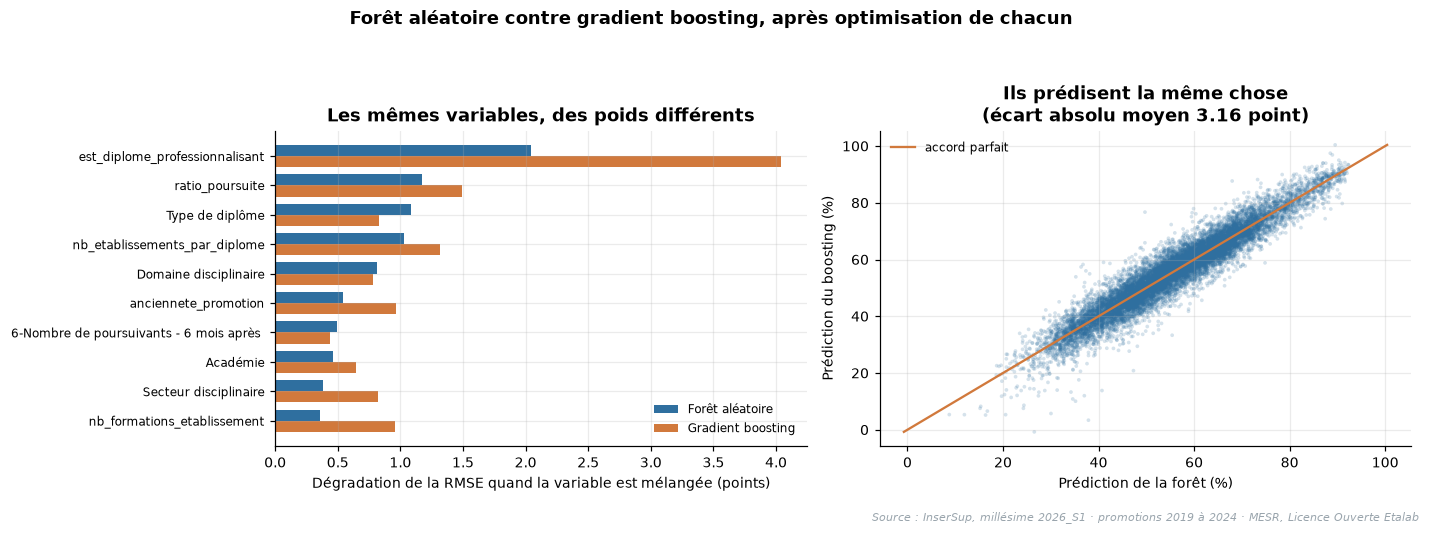

In [8]:
sommet = comparaison_importances.head(10).iloc[::-1]
positions = np.arange(len(sommet))
hauteur = 0.38

figure, axes = plt.subplots(1, 2, figsize=(13, 4.6))

axes[0].barh(positions + hauteur / 2, sommet['forêt'], hauteur,
             label='Forêt aléatoire', color=COULEUR)
axes[0].barh(positions - hauteur / 2, sommet['boosting'], hauteur,
             label='Gradient boosting', color=COULEUR_ALT)
axes[0].set_yticks(positions)
axes[0].set_yticklabels([nom[:40] for nom in sommet.index], fontsize=8)
axes[0].set_xlabel('Dégradation de la RMSE quand la variable est mélangée (points)')
axes[0].set_title('Les mêmes variables, des poids différents')
axes[0].legend(frameon=False, fontsize=8)

axes[1].scatter(oof_foret, oof_boosting, s=6, alpha=0.2, color=COULEUR, edgecolor='none')
limites = [min(oof_foret.min(), oof_boosting.min()), max(oof_foret.max(), oof_boosting.max())]
axes[1].plot(limites, limites, color=COULEUR_ALT, linewidth=1.5, label='accord parfait')
axes[1].set_xlabel('Prédiction de la forêt (%)')
axes[1].set_ylabel('Prédiction du boosting (%)')
axes[1].set_title(f'Ils prédisent la même chose\n(écart absolu moyen '
                  f'{ecart_modeles.mean():.2f} point)')
axes[1].legend(frameon=False, fontsize=8)

figure.suptitle('Forêt aléatoire contre gradient boosting, après optimisation de chacun',
                fontsize=12, fontweight='bold')
figure.tight_layout(rect=(0, 0, 1, 0.93))
annoter_source()
plt.savefig(FIGURE_PATH / 'fig18_duel_foret_boosting.png')
plt.show()

---

## 6. Décision : la forêt aléatoire est conservée

| Modèle | MAE | RMSE | R² | à ±5 pts | ratées de +15 pts |
|---|---:|---:|---:|---:|---:|
| Forêt optimisée | 9,439 | 12,278 | 0,557 | 35,2 % | 20,6 % |
| Boosting optimisé | 9,241 | 12,005 | 0,577 | 35,3 % | 19,4 % |
| Moyenne des deux | 9,199 | 11,963 | 0,580 | 35,8 % | 19,5 % |

**Les deux modèles se ressemblent énormément.** C'est le résultat principal de cette étape,
et il est mesuré sous quatre angles qui concordent :

- leurs prédictions corrèlent à **0,953**, pour un écart absolu moyen de **3,16 points** ;
- elles ne divergent de plus de 10 points que sur **2,4 %** des formations ;
- ils s'appuient sur les mêmes variables, avec une corrélation des rangs d'importance de
  **0,905** ;
- sur 14 découpages par taille, domaine et promotion, l'écart médian entre eux est de
  **0,15 point de MAE**, quand l'erreur elle-même est de 9,4.

Autrement dit, ce sont deux lectures très voisines du même signal. Sur une formation
donnée, il est rare que le choix du modèle change la réponse de plus d'un ou deux points.

**L'écart mesuré penche pour le boosting, mais il est ténu.** 0,198 point de MAE, soit 2 %
de l'erreur, environ 1,3 fois l'écart-type entre plis. Sa régularité est ce qui lui donne du
poids : il tient sur 13 des 14 découpages. Un écart faible mais partout vaut mieux qu'un
écart isolé.

### Pourquoi garder la forêt malgré cela

**1. Le seul score mesuré sur le jeu de test est celui de la forêt : 9,579 points de MAE.**
Celui du boosting n'existe qu'en validation croisée. Échanger un résultat mesuré contre une
estimation, pour 2 %, serait troquer une certitude contre une promesse.

**2. Le jeu de test n'a été ouvert qu'une fois.** Le rouvrir pour départager rendrait le
score final légèrement optimiste et ferait perdre au projet une garantie méthodologique qui
vaut plus que 0,2 point de MAE.

**3. Le gain est invisible à l'usage.** L'erreur passerait de 9,58 à environ 9,4 points sur
une cible qui varie de 0 à 100. Aucun utilisateur ne lirait la différence, alors que tous
liraient l'incohérence d'un protocole abandonné en cours de route.

**Ce que ce choix coûte, et il faut l'assumer** : environ 0,2 point de MAE, et le fait que
le modèle livré n'est probablement pas le meilleur atteignable sur ces données. C'est écrit
ici plutôt que masqué, parce qu'un choix documenté se défend, et qu'un choix caché se
découvre.

### La leçon la plus utile de cette étape

L'optimisation rapporte 0,056 point à la forêt et **0,277 au boosting**, cinq fois plus. Le
classement de l'étape 4 ne comparait donc pas deux potentiels, il comparait un modèle déjà
proche de son plafond à un modèle mal réglé. **Comparer des modèles non optimisés ne dit rien
de ce qu'ils valent**, et c'est vrai bien au-delà de ce projet.